In [1]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import heapq
import copy

**7.5 An Inventory Model**

Consider a shop that stocks a particular type of product that it sells for a price of r per unit. Customers demanding this product appear in accordance with a Poisson process with rate λ, and the amount demanded by each one is a random variable having distribution G. In order to meet demands, the shopkeeper must keep an amount of the product on hand, and whenever the on-hand inventory becomes low, additional units are ordered from the distributor. The shopkeeper uses a so-called (s, S) ordering policy; namely, whenever the on-hand inventory is less than s and there is no presently outstanding order, then an amount is ordered to bring it up to S, where s < S. That is, if the present inventory level is x and no order is outstanding, then if x < s the amount S − x is ordered. The cost of ordering y units of the product is a speciﬁed function c(y), and it takes L units of time until the order is delivered, with the payment being made upon delivery. In addition, the shop pays an inventory holding cost of h per unit item per unit time. Suppose further that whenever a customer demands more of the product than is presently available, then the amount on hand is sold and the remainder of the order is lost to the shop.

Let us see how we can use simulation to estimate the shop’s expected proﬁt up to some ﬁxed time T . To do so, we start by deﬁning the variables and events as follows.


In [60]:
class InventoryStockSimulator:
    def __init__(self, customer_function, demand_function, order_cost_function, L, r, s, S, h, x, closing_time):
        
        # Parameters
        self.customer_function = customer_function
        self.demand_function = demand_function
        self.order_time_arrival = L
        self.order_cost_function = order_cost_function
        self.sell_price_per_unit = r
        self.order_policy = { 's': s, 'S': S}
        self.holding_cost_per_unit = h
        self.closing_time = closing_time
        self.initial_inventory_amount = x
        
    
    def initialize_variables(self):
        # System State Variables
        self.inventory_amount = self.initial_inventory_amount
        self.order_amount = 0
        
        # Counter Variables
        self.total_order_amount = 0
        self.total_inventory_holding_cost = 0
        self.total_revenue = 0
        self.total_lost_order_amount = 0
        
        # Events Variables
        self.time = 0
        self.events_queue = []
    
    def simulate(self):
        
        self.initialize_variables()
        self.order_pending = False
        
        heapq.heappush(self.events_queue, (self.customer_function(), 'customer'))
        
        while self.events_queue:
            current_time, event_type = heapq.heappop(self.events_queue)
            
            if event_type == "customer":
                
                self.total_inventory_holding_cost = self.total_inventory_holding_cost + (current_time - self.time) * self.inventory_amount * self.holding_cost_per_unit
                self.time = current_time
                
                demand = self.demand_function()
                w = min(demand, self.inventory_amount)
                self.total_revenue += w * self.sell_price_per_unit
                self.total_lost_order_amount += (demand - w)*self.sell_price_per_unit
                self.inventory_amount -= w
                
                if self.inventory_amount < self.order_policy['s'] and not self.order_pending:
                    self.order_amount = self.order_policy['S'] - self.inventory_amount
                    heapq.heappush(self.events_queue, (current_time + self.order_time_arrival, 'order'))
                    self.order_pending = True
                
                if self.time < self.closing_time:
                    heapq.heappush(self.events_queue, (current_time + self.customer_function(), 'customer'))

            else:
                self.total_inventory_holding_cost += (current_time - self.time) * self.inventory_amount * self.holding_cost_per_unit
                self.time = current_time
                
                self.total_order_amount += self.order_cost_function(self.order_amount)
                self.inventory_amount += self.order_amount
                self.order_amount = 0
                self.order_pending = False
                
                if self.inventory_amount < self.order_policy['s']:
                    self.order_amount = self.order_policy['S'] - self.inventory_amount
                    heapq.heappush(self.events_queue, (current_time + self.order_time_arrival, 'order'))

        return {
            "revenue": self.total_revenue,
            "holding_cost": self.total_inventory_holding_cost,
            "lost_revenue": self.total_lost_order_amount,
            "order_cost": self.total_order_amount,
            "net_profit": self.total_revenue - self.total_inventory_holding_cost - self.total_order_amount,
            "net_profit_per_time": (self.total_revenue - self.total_inventory_holding_cost - self.total_order_amount) / self.closing_time        }


In [61]:
def customer_arrival_function(lamb = 1.0): 
    return np.random.exponential(lamb)

def demand_function(low = 1, high = 5):
    return np.random.randint(low, high)
         
def order_cost_function(y):
    return 5 + 2 * y 

In [67]:
sim = InventoryStockSimulator(
    customer_function=customer_arrival_function,
    demand_function=demand_function,
    order_cost_function=order_cost_function,
    L=2,  # tiempo de entrega
    r=10,  # precio por unidad vendida
    s=5,  # nivel mínimo de inventario
    S=20,  # nivel al que se repone
    h=0.1,  # costo de almacenamiento por unidad por tiempo
    x=10,  # inventario inicial
    closing_time=100  # tiempo total de simulación
)

result = sim.simulate()
for i in result:
    print(f"{i}: {result[i]}")

revenue: 2480
holding_cost: 87.6027198391043
lost_revenue: 390
order_cost: 581
net_profit: 1811.3972801608957
net_profit_per_time: 18.113972801608956


revenue [ mean : 2175.13 , std : 200.53 ]
holding_cost [ mean : 92.88 , std : 5.05 ]
lost_revenue [ mean : 342.17 , std : 121.92 ]
order_cost [ mean : 506.74 , std : 47.17 ]
net_profit [ mean : 1575.51 , std : 157.81 ]
net_profit_per_time [ mean : 15.76 , std : 1.58 ]


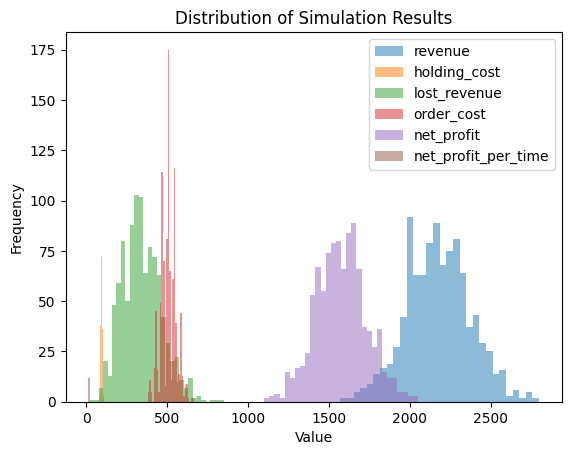

In [74]:
num_simulations = 1000
results = []  # Para almacenar los resultados de cada simulación

for i in range(num_simulations):
    sim = InventoryStockSimulator(customer_arrival_function, demand_function, order_cost_function,
                                  L=2, r=10, s=5, S=20, h=0.1, x=10, closing_time=100)
    result = sim.simulate()
    results.append(result)

for i in results[0]:
    stats = [res[i] for res in results]
    print(f"{i} [ mean : {np.mean(stats):.2f} , std : {np.std(stats):.2f} ]")
    plt.hist(stats, bins=30, alpha=0.5, label=i)
plt.legend()
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.title('Distribution of Simulation Results')
plt.show()


In [75]:
class Product:
    def __init__(self, initial_inventory, sell_prices, holding_cost, s, S):
        # Initial Parameters
        self.initial_inventory_amount = initial_inventory
        self.sell_prices_per_unit = sell_prices
        self.holding_cost_per_unit = holding_cost
        self.S = S
        self.s = s
        
        self.reset_simulation_parameters()
        
    def reset_simulation_parameters(self):
        self.actual_inventory_amount = self.initial_inventory_amount
        
        self.total_inventory_holding_cost = 0
        self.total_order_amount = 0
        self.total_revenue = 0
        self.total_lost_amount = 0
    
    def charge_holding_cost(self, time):
        self.total_inventory_holding_cost += time * self.holding_cost_per_unit * self.actual_inventory_amount

In [76]:
class InventoryKStockSimulator:
    def __init__(self, customer_arrival_function, customer_demand_function, product_demand_function, order_cost_function, 
                products: list["Product"], order_time_arrival: int, closing_time: int):
        
        # Parameters
        self.customer_arrival_function = customer_arrival_function
        self.customer_demand_function = customer_demand_function
        self.product_demand_function = product_demand_function
        self.order_cost_function = order_cost_function
        self.order_time_arrival = order_time_arrival
        self.products_list = products
        self.closing_time = closing_time
        
    
    def initialize_variables(self):
        # System State Variables
        for product in self.products_list:
            product.reset_simulation_parameters()
        
        # Events Variables
        self.time = 0
        self.events_queue = []
        
    
    def process_customer(self, current_time):
        
        for product_id in self.customer_demand_function():
            
            product = self.products_list[product_id]
            
            product.charge_holding_cost(current_time - self.time)

            demand = self.product_demand_function()
            w =  min(demand, product.actual_inventory_amount, 0)
            product.total_revenue += w * product.sell_prices_per_unit
            product.total_lost_amount += (demand - w) * product.sell_prices_per_unit
            product.actual_inventory_amount -= w
            
            
            if product.actual_inventory_amount < product.s:
                amount = product.S - product.actual_inventory_amount
                heapq.heappush(self.events_queue, (current_time + self.order_time_arrival, 'order', (product_id, amount)))
            
            if self.time < self.closing_time:
                heapq.heappush(self.events_queue, (current_time + self.customer_arrival_function(), 'customer'))
            
        self.time = current_time
            
            
            
    def process_order(self, current_time, product_id, amount):
        
        product = self.products_list[product_id]
        
        product.charge_holding_cost(current_time - self.time)
        
        product.total_order_amount += self.order_cost_function(amount)
        product.actual_inventory_amount += amount
        
        
        if product.actual_inventory_amount < product.s:
            amount = product.S - product.actual_inventory_amount
            heapq.heappush(self.events_queue, (current_time + self.order_time_arrival, 'order', product_id, amount))
            
        self.time = current_time

    
    def simulate(self):
        
        self.initialize_variables()
        
        heapq.heappush(self.events_queue, (self.customer_arrival_function(), 'customer'))
        
        while self.events_queue:
            event = heapq.heappop(self.events_queue)
            
            if event[1] == "customer":
                self.process_customer(event[0])
            else:
                self.process_order(event[0], event[2], event[3])

        return copy.deepcopy(self.products_list)